# 0. Libraries

## 0.1 Libraries Import

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

from scipy.stats import randint
import statsmodels.api as sm

import markdown

import warnings
warnings.filterwarnings('ignore')


In [162]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge

from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier, RandomForestClassifier 
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.pipeline import Pipeline
impipeline = Pipeline

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import category_encoders as ce

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler

from collections import defaultdict

from sklearn import metrics
from sklearn.metrics import accuracy_score, roc_curve, RocCurveDisplay, roc_auc_score, mean_squared_error
from sklearn.metrics import f1_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, fbeta_score
from sklearn.metrics import make_scorer
f2_scorer = make_scorer(fbeta_score, beta=2)

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_validate

import shap

from scipy.stats import chi2_contingency, pointbiserialr

import dice_ml
from dice_ml import Data, Model, Dice

## 0.2. Load Data

In [4]:
df_bank = pd.read_csv('bank-additional-full.csv', sep=';')

# 1. Business Benchmark - Bank Marketing Campaign

## 1.1. Title

In [5]:
mean_telephone_minutedur = df_bank[df_bank['contact']=='telephone']['duration'].mean()/60
mean_cellular_minutedur = df_bank[df_bank['contact']=='cellular']['duration'].mean()/60
print(f'mean Telephone duration (minute) : {mean_telephone_minutedur}')
print(f'mean Cellular duration (minute) : {mean_cellular_minutedur}')

mean Telephone duration (minute) : 4.152897057520163
mean Cellular duration (minute) : 4.392130762953896


In [6]:
mean_telephone_campaigncall = df_bank[df_bank['contact']=='telephone']['campaign'].mean()
mean_cellular_campaigncall = df_bank[df_bank['contact']=='cellular']['campaign'].mean()
print(f'mean Telephone campaign call : {mean_telephone_campaigncall}')
print(f'mean Cellular campaign call : {mean_cellular_campaigncall}')

mean Telephone campaign call : 2.8501063546929006
mean Cellular campaign call : 2.405026009791922


In [7]:
cent_to_eur = 0.0015
cost_tel = mean_telephone_minutedur * 1.9 * cent_to_eur
cost_cell = mean_cellular_minutedur * 30.04 * cent_to_eur
print(f'Cost Mean Telephone : {cost_tel}')
print(f'Cost Mean Cellular : {cost_cell}')

Cost Mean Telephone : 0.011835756613932465
Cost Mean Cellular : 0.19790941217870256


In [8]:
bank_profit = 250 * 0.0279
round(bank_profit, 3)

6.975

In [9]:
call_cost = ((cost_tel+cost_cell)/2)
print(round(call_cost, 3))

0.105


## 1.2 Title

In [10]:
#actual comparison

#total duration in minute (with mean)
sum_telephone_minutedur = df_bank[df_bank['contact']=='telephone']['campaign'].sum() * mean_telephone_minutedur
sum_cellular_minutedur = df_bank[df_bank['contact']=='cellular']['campaign'].sum() * mean_cellular_minutedur

#total cost in euro
cost_tel_sum = sum_telephone_minutedur * 1.9 * cent_to_eur
cost_cell_sum = sum_cellular_minutedur * 30.04 * cent_to_eur

total_cost_sum = (cost_tel_sum + cost_cell_sum).round()

#---

#Profits
original_deposit_profit = df_bank[df_bank['y']=='yes']['y'].count() * bank_profit

#Net Profit
original_net_profit = (original_deposit_profit - total_cost_sum).round()

#Revenue
original_revenue = original_deposit_profit = df_bank[df_bank['y']=='yes']['y'].count() * 250

#Net Revenue
original_net_rev = original_revenue -total_cost_sum

#Conversion Rate
original_conv_rate = (df_bank[df_bank['y']=='yes']['y'].count() / (df_bank['y'].count())).round(2)

#ROI
original_roi = ( original_net_rev /total_cost_sum ).round(2)

#Net ROI
original_net_roi = ( original_net_profit / total_cost_sum ).round(2)

In [11]:
campaign_summary_data = [
                        ['Total Deposit', original_revenue],
                        ['Deposit Profit', original_net_rev],
                        ['Expenses', total_cost_sum],
                        ['ROI', original_roi],
                        ['Net ROI', original_net_roi],
                        ['Conversion Rate', original_conv_rate],
                        ]
campaign_summary = pd.DataFrame(campaign_summary_data, columns=['Metric', 'Value'])

campaign_summary

,Metric,Value
0,Total Deposit,1160000.00
1,Deposit Profit,1147049.00
2,Expenses,12951.00
3,ROI,88.57
4,Net ROI,1.50
5,Conversion Rate,0.11


### Functions to calculate ROI & Conversion Rate

In [12]:
def conv_rate_func(y_true, y_pred):
    # Confusion Matrix Components
    TP = sum((y_true == 1) & (y_pred == 1))
    FP = sum((y_true == 0) & (y_pred == 1))
    conv_rate = (TP / (TP + FP)) * 100
    return conv_rate

In [13]:
def roi_func(y_true, y_pred):
    # Confusion Matrix Components
    TP = sum((y_true == 1) & (y_pred == 1))
    FP = sum((y_true == 0) & (y_pred == 1))

    total_profit = TP * bank_profit
    total_cost = (TP + FP) * bank_cost

    roi = (total_profit - total_cost) / total_cost
    return roi

In [14]:
cent_to_eur = 0.0015
cost_tel = mean_telephone_minutedur * 1.9 * cent_to_eur
cost_cell = mean_cellular_minutedur * 30.04 * cent_to_eur
bank_cost = ((cost_tel+cost_cell)/2)
bank_cost = round(bank_cost, 3)

# 2. Preprocessing

In [15]:
df = df_bank.copy()

## 2.1. Data Cleaning

In [16]:
df.y = df.y.map({'no':0, 'yes':1}).astype('int64')

In [17]:
df['education'] = df['education'].map(
            {'unknown': 1, 
            'illiterate': 1, 
            'basic.4y': 2, 
            'basic.6y': 3, 
            'basic.9y': 4, 
            'high.school': 5, 
            'professional.course': 6, 
            'university.degree': 7})

df['month'] = df['month'].map(
            {'jan': 1,
            'feb': 2,
            'mar': 3,
            'apr': 4,
            'may': 5,
            'jun': 6,
            'jul': 7,
            'aug': 8,
            'sep': 9,
            'oct': 10,
            'nov': 11,
            'dec': 12})

df['day_of_week'] = df['day_of_week'].map(
            {'mon': 1,
            'tue': 2,
            'wed': 3,
            'thu': 4,
            'fri': 5,
            'sat': 6,
            'sun': 7})


#### New Feature Creation

In [18]:
df['past_contacted'] = df['poutcome'].map({
    'nonexistent': 0, 
    'failure': 1, 
    'success': 1
})


## 2.2. Feature Engineering

In [19]:
df_modified = df.copy()

### 2.2.1 Dropping Features

In [20]:
# df_modified = df.drop(columns=['poutcome', 'duration','default','pdays', 'previous' ,'loan', 'housing'])

### 2.2.2. RobustScaler Preparation - Outlier

In [21]:
def calculate_outlier_percentage(df):

    outlier_percentages = {}
    for column in df.select_dtypes(include=np.number).columns:  
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

        # Get percentage of outliers
        total_rows = len(df)
        num_outliers = len(outliers)
        
        if total_rows > 0:
            percentage = (num_outliers / total_rows) * 100
        else:
            percentage = 0  # Handle empty case

        outlier_percentages[column] = percentage
    
    return pd.Series(outlier_percentages)


# Calculate percentage
outliers = calculate_outlier_percentage(df_modified).reset_index()
outlier_columns = outliers[ (outliers[0]>0) & (outliers['index']!='y') & (outliers['index']!='duration')]['index']
outlier_list = outlier_columns.tolist()
outlier_list

['age', 'campaign', 'pdays', 'previous', 'cons.conf.idx', 'past_contacted']

In [22]:
drop_list = ['poutcome', 'duration','default','pdays', 'previous' ,'loan', 'housing']

In [23]:
outlier_list = list(filter(lambda item: item not in drop_list, outlier_list))

### 2.2.3. Preprocessing Pipeline

In [24]:
df_modified.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'past_contacted'],
      dtype='object')

In [25]:
# Pipelining
preprocessor = ColumnTransformer(
    [
        # ('drop_columns', 'drop', ['poutcome', 'duration','default','pdays', 'previous' ,'loan', 'housing']),
        ('onehot_encoding', OneHotEncoder(drop='first', sparse_output=False), ['marital', 'contact']),
        ('binary_encoding', ce.BinaryEncoder(), ['job']),
        ('scaler', RobustScaler(), outlier_list),
        ('passthrough_col', 'passthrough', list(set(['age', 'campaign', 'cons.conf.idx', 'past_contacted', 
                                            'education', 'month', 'day_of_week', 'emp.var.rate', 'cons.price.idx',
                                            'euribor3m', 'nr.employed']
                                            ).difference(outlier_list))
            )
    ],
    remainder='drop', verbose_feature_names_out=False)

preprocessor

,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,False


In [26]:
# Preprocessing Check

df_preproc_check = df_modified.copy()


pipecheck = impipeline(steps=[
    ('feature engineering', preprocessor)
    ])


df_transformed_array = pipecheck.fit_transform(df_preproc_check)
df_transformed_array = pd.DataFrame(df_transformed_array)
pipecheck.named_steps['feature engineering'].get_feature_names_out()

array(['marital_married', 'marital_single', 'marital_unknown',
       'contact_telephone', 'job_0', 'job_1', 'job_2', 'job_3', 'age',
       'campaign', 'cons.conf.idx', 'past_contacted', 'day_of_week',
       'euribor3m', 'nr.employed', 'month', 'emp.var.rate',
       'cons.price.idx', 'education'], dtype=object)

In [27]:
transformed_data = pipecheck.fit_transform(df_preproc_check)
transformed_datadf = pd.DataFrame(transformed_data, columns=pipecheck.named_steps['feature engineering'].get_feature_names_out(), index=df.index)
transformed_datadf

,marital_married,marital_single,marital_unknown,contact_telephone,job_0,job_1,job_2,job_3,age,campaign,cons.conf.idx,past_contacted,day_of_week,euribor3m,nr.employed,month,emp.var.rate,cons.price.idx,education
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.200000,-0.5,0.857143,0.0,1.0,4.857,5191.0,5.0,1.1,93.994,2.0
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.266667,-0.5,0.857143,0.0,1.0,4.857,5191.0,5.0,1.1,93.994,5.0
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,-0.066667,-0.5,0.857143,0.0,1.0,4.857,5191.0,5.0,1.1,93.994,5.0
3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.133333,-0.5,0.857143,0.0,1.0,4.857,5191.0,5.0,1.1,93.994,3.0
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.200000,-0.5,0.857143,0.0,1.0,4.857,5191.0,5.0,1.1,93.994,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,2.333333,-0.5,-1.428571,0.0,5.0,1.028,4963.6,11.0,-1.1,94.767,6.0
41184,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.533333,-0.5,-1.428571,0.0,5.0,1.028,4963.6,11.0,-1.1,94.767,6.0
41185,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.200000,0.0,-1.428571,0.0,5.0,1.028,4963.6,11.0,-1.1,94.767,7.0
41186,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.400000,-0.5,-1.428571,0.0,5.0,1.028,4963.6,11.0,-1.1,94.767,6.0


#### 3.1.3 Pipeline

In [28]:
pipe = Pipeline(steps=[
    ('feature engineering', preprocessor)
    ])
pipe

,steps,"[('feature engineering', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


### 2.2.4. Sampling Pipeline

In [29]:
smote_pipe = impipeline(steps=[
    ('smote', SMOTE(sampling_strategy = 1, random_state=2042),)
])

smote_pipe_steps = smote_pipe.steps

In [30]:
tomeklinks_pipe = impipeline(steps=[
    ('tomeklinks', TomekLinks(sampling_strategy = 'majority'))
])

tomeklinks_pipe_steps = tomeklinks_pipe.steps

### 2.2.5. Train-Test Split

In [31]:
# Creating a new dataframe for further operation
df_split = df_modified.copy()

In [32]:
# duration will be removed from this point forward
# df_split = df_split.drop(columns=['duration'])

In [33]:
# Train-test split

y = df_split['y']
X = df_split.drop(columns=['y'])


X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=2042)

In [34]:
X_train

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted
11491,37,services,married,5,no,unknown,unknown,telephone,6,5,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,0
24682,35,blue-collar,married,5,unknown,yes,no,cellular,11,1,...,2,999,1,failure,-0.1,93.200,-42.0,4.191,5195.8,1
37911,34,technician,married,6,no,yes,no,cellular,9,3,...,2,999,0,nonexistent,-3.4,92.379,-29.8,0.813,5017.5,0
519,42,admin.,married,1,no,no,no,telephone,5,2,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
8013,37,admin.,married,7,no,yes,no,telephone,6,1,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.865,5228.1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,50,blue-collar,divorced,2,no,no,no,telephone,6,3,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,0
25704,44,admin.,single,7,no,no,no,cellular,11,3,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,0
36747,47,admin.,single,7,no,yes,no,cellular,6,1,...,4,999,0,nonexistent,-2.9,92.963,-40.8,1.281,5076.2,0
32334,42,blue-collar,married,2,unknown,no,no,cellular,5,5,...,1,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,0


# 3. Model Experimentation

## 3.1. Benchmark Metrics

### 3.1.1. Declaring Variables

In [35]:
#actual comparison

#total duration in minute (with mean)
unseen_sum_telephone_minutedur = X_test[X_test['contact']=='telephone']['campaign'].sum() * mean_telephone_minutedur
unseen_sum_cellular_minutedur = X_test[X_test['contact']=='cellular']['campaign'].sum() * mean_cellular_minutedur

#total cost in euro
unseen_cost_tel_sum = unseen_sum_telephone_minutedur * 1.9 * cent_to_eur
unseen_cost_cell_sum = unseen_sum_cellular_minutedur * 30.04 * cent_to_eur

unseen_total_cost_sum = (unseen_cost_tel_sum + unseen_cost_cell_sum).round()

#---

#Profits
unseen_deposit_profit = y_test[y_test==1].count() * bank_profit

#Net Profit
unseen_net_profit = (unseen_deposit_profit - unseen_total_cost_sum).round()

#Revenue
unseen_revenue = unseen_deposit_profit = y_test[y_test==1].count() * 250

#Net Revenue
unseen_net_rev = unseen_revenue - unseen_total_cost_sum

#Conversion Rate
unseen_conv_rate = (y_test[y_test==1].count() / (y_test[y_test==1].count() + y_test[y_test==0].count())).round(2)

#ROI
unseen_roi = ( unseen_net_rev / unseen_total_cost_sum).round(2)

#Net ROI
unseen_net_roi = ( unseen_net_profit / unseen_total_cost_sum).round(2)

### 3.1.2. Business Metrics with Test Set

In [36]:
unseen_summary_data = [
                        ['Total Deposit', unseen_revenue],
                        ['Deposit Profit', unseen_net_rev],
                        ['Expenses', unseen_total_cost_sum],
                        ['ROI', unseen_roi],
                        ['Net ROI', unseen_net_roi],
                        ['Conversion Rate', unseen_conv_rate],
                        ]
unseen_summary = pd.DataFrame(unseen_summary_data, columns=['Metric (Unseen Data)', 'Value'])
unseen_summary

,Metric (Unseen Data),Value
0,Total Deposit,232000.00
1,Deposit Profit,229422.00
2,Expenses,2578.00
3,ROI,88.99
4,Net ROI,1.51
5,Conversion Rate,0.11


## 3.2. Model Runs

### List of Models

In [37]:
#List of models
models=[
    #Ensemble
    ('AdaBoost', AdaBoostClassifier(random_state=2042)),
    ('Bagging Classifier', BaggingClassifier(random_state=2042)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=2042)),
    ('Random Forest', RandomForestClassifier(random_state=2042)),
    
    #Linear
    ('Logistic Regression', LogisticRegression(random_state=2042)),

    #Decision Tree
    ('Decision Tree Entropy', DecisionTreeClassifier(criterion = 'entropy', random_state = 2042)),
    ('Decision Tree Gini', DecisionTreeClassifier(criterion = 'gini', random_state = 2042)),
    
    #XGBoost
    ('XGBoost', XGBClassifier(random_state=2042)),
]

scoring_list = ['precision', 'recall', 'f1', f2_scorer]

### Models Score

In [38]:
# With SMOTE
results_sm = defaultdict(list)

for m_name, m in models:
    
    complete_steps_smote = pipe.steps + smote_pipe_steps + [('classifier', m)]
    complete_pipeline_smote = impipeline(steps=complete_steps_smote)

    f1_score_smote = cross_val_score(complete_pipeline_smote, X_train, y_train, cv=5, scoring='f1')
    f2_score_smote = cross_val_score(complete_pipeline_smote, X_train, y_train, cv=5, scoring=f2_scorer)

    # RESULTS
    results_sm['Model'].append( m_name )
    
    results_sm['F1 Score Mean'].append( f1_score_smote.mean() )
    results_sm['F1 Score Stdev'].append( f1_score_smote.std() )
    # results_sm['F2 Score Mean'].append( f2_score_smote.mean() )
    # results_sm['F2 Score Stdev'].append( f2_score_smote.mean() )


############################################################################################
results_df_smote = pd.DataFrame(results_sm)
results_df_smote = results_df_smote.sort_values(by='F1 Score Mean', ascending=False)

print("with SMOTE")
results_df_smote
############################################################################################

with SMOTE


,Model,F1 Score Mean,F1 Score Stdev
2,Gradient Boosting,0.480751,0.008646
0,AdaBoost,0.460921,0.007800
7,XGBoost,0.413753,0.016193
3,Random Forest,0.408316,0.009954
4,Logistic Regression,0.378485,0.007657
1,Bagging Classifier,0.368053,0.014027
6,Decision Tree Gini,0.320430,0.017742
5,Decision Tree Entropy,0.315703,0.019013


### Model Selection

In [39]:
base_check = {}
model_tests=[
    ('AdaBoost', AdaBoostClassifier(random_state=2042)),
    ('Gradient Boosting', GradientBoostingClassifier(random_state=2042))
    ]

In [40]:
def train_test_diff(mname, mdl):

    complete_steps_modelselected = pipe.steps + smote_pipe_steps + [('classifier', mdl)]
    pipeline_modelselected= impipeline(steps=complete_steps_modelselected)

    pipeline_modelselected.fit(X_train, y_train)

    y_train_basemodel = pipeline_modelselected.predict(X_train)
    y_test_basemodel = pipeline_modelselected.predict(X_test)

    # Get F1 Score for both train and test sets, get the difference
    train_basemodel = f1_score(y_train, y_train_basemodel)
    test_basemodel = f1_score(y_test, y_test_basemodel)
    diff_basemodel = abs( train_basemodel - test_basemodel )
    
    ttd = {
        
        mname: [mname, round(train_basemodel, 4), round(test_basemodel, 4), round(diff_basemodel, 4)]
    }

    ttd_df = pd.DataFrame(ttd)

    return ttd

In [41]:
base_check = {"Metric": ['Model', 'Train Base Model Score', 'Test Base Model Score', 'Score Difference']}
for mname, modol in model_tests:
    ttd = train_test_diff(mname, modol)
    base_check[modol] = ttd[mname]


# Create DataFrame
df_base_check = pd.DataFrame(base_check)
df_base_check

Metric  \
0                   Model   
1  Train Base Model Score   
2   Test Base Model Score   
3        Score Difference   

  (DecisionTreeClassifier(max_depth=1, random_state=1201040990), DecisionTreeClassifier(max_depth=1, random_state=1195384687), DecisionTreeClassifier(max_depth=1, random_state=520153871), DecisionTreeClassifier(max_depth=1, random_state=616221267), DecisionTreeClassifier(max_depth=1, random_state=150984724), DecisionTreeClassifier(max_depth=1, random_state=1959841328), DecisionTreeClassifier(max_depth=1, random_state=502720939), DecisionTreeClassifier(max_depth=1, random_state=1553252037), DecisionTreeClassifier(max_depth=1, random_state=1778420591), DecisionTreeClassifier(max_depth=1, random_state=154853632), DecisionTreeClassifier(max_depth=1, random_state=1434893881), DecisionTreeClassifier(max_depth=1, random_state=639447088), DecisionTreeClassifier(max_depth=1, random_state=1814229768), DecisionTreeClassifier(max_depth=1, random_state=1801767573), DecisionTreeClassifier(max_depth=1, random_state=1668684931), DecisionTreeClassifier(max_depth=1, random_state=1159532564), DecisionTreeClassifier(max_depth=1, random_state=434924014), DecisionTreeClassifier(max_depth=1, random_state=2119743359), DecisionTreeClassifier(max_depth=1, random_state=204964498), DecisionTreeClassifier(max_depth=1, random_state=1768863051), DecisionTreeClassifier(max_depth=1, random_state=2145709151), DecisionTreeClassifier(max_depth=1, random_state=2065712023), DecisionTreeClassifier(max_depth=1, random_state=1930259960), DecisionTreeClassifier(max_depth=1, random_state=2077412000), DecisionTreeClassifier(max_depth=1, random_state=1825827774), DecisionTreeClassifier(max_depth=1, random_state=907093955), DecisionTreeClassifier(max_depth=1, random_state=2124535834), DecisionTreeClassifier(max_depth=1, random_state=1751086209), DecisionTreeClassifier(max_depth=1, random_state=48271713), DecisionTreeClassifier(max_depth=1, random_state=1883293623), DecisionTreeClassifier(max_depth=1, random_state=1534668251), DecisionTreeClassifier(max_depth=1, random_state=106759214), DecisionTreeClassifier(max_depth=1, random_state=459783599), DecisionTreeClassifier(max_depth=1, random_state=727921012), DecisionTreeClassifier(max_depth=1, random_state=1719725575), DecisionTreeClassifier(max_depth=1, random_state=173590430), DecisionTreeClassifier(max_depth=1, random_state=555900171), DecisionTreeClassifier(max_depth=1, random_state=499100862), DecisionTreeClassifier(max_depth=1, random_state=1634128839), DecisionTreeClassifier(max_depth=1, random_state=2076400895), DecisionTreeClassifier(max_depth=1, random_state=1878632913), DecisionTreeClassifier(max_depth=1, random_state=538176230), DecisionTreeClassifier(max_depth=1, random_state=230254856), DecisionTreeClassifier(max_depth=1, random_state=1290649542), DecisionTreeClassifier(max_depth=1, random_state=736401271), DecisionTreeClassifier(max_depth=1, random_state=831739328), DecisionTreeClassifier(max_depth=1, random_state=1623867479), DecisionTreeClassifier(max_depth=1, random_state=1961342099), DecisionTreeClassifier(max_depth=1, random_state=1002081315), DecisionTreeClassifier(max_depth=1, random_state=1452431318))  \
0                                           AdaBoost                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

# 4. Hyperparameter Tuning Experimentation

## 4.1. AdaBoost

### 4.1.1 Declaring Tuning Pipeline

In [131]:
# param_ada_randomizedsearch = {
#     'n_estimators': [50, 100, 200],
#     'learning_rate': [0.01, 0.1, 0.2],
# }

# param_ada_randomizedsearch = {
#     'n_estimators': [50, 100, 150],
#     'learning_rate': [0.1, 0.2, 0.3],
# }

#best
# param_ada_randomizedsearch = {
#     'n_estimators': [100, 150, 200],
#     'learning_rate': [0.3, 0.4, 0.5],
# }

# param_ada_randomizedsearch = {
#     'n_estimators': [150, 200, 250, 300, 350],
#     'learning_rate': [0.2, 0.3, 0.4, 0.5, 0.6, 0.7],
# }

param_ada_randomizedsearch = {
    'n_estimators': [300, 350, 400, 450],
    'learning_rate': [0.5, 0.6, 0.7, 0.8],
}

In [132]:
ada_randomizedsearch_steps = pipe.steps + smote_pipe_steps + [('classifier', RandomizedSearchCV(AdaBoostClassifier(), param_ada_randomizedsearch, n_iter=10, cv=5, scoring='f1'))]
ada_randomizedsearch_pipe = impipeline(steps=ada_randomizedsearch_steps)

### 4.1.2. Hyperparameter Tuning

In [133]:
ada_randomizedsearch = ada_randomizedsearch_pipe.fit(X_train, y_train)

In [134]:
ada_randomizedsearch[2].best_score_

np.float64(0.8525119805727381)

In [135]:
ada_randomizedsearch[2]

,estimator,AdaBoostClassifier()
,param_distributions,"{'learning_rate': [0.5, 0.6, ...], 'n_estimators': [300, 350, ...]}"
,n_iter,10
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [136]:
best_ada_randomizedsearch = ada_randomizedsearch[2].best_estimator_
ada_rs_best_steps = pipe.steps + smote_pipe_steps + [('AdaBoost RandomizedSearch', best_ada_randomizedsearch)]
ada_rs_best_pipe = impipeline(steps=ada_rs_best_steps)
# .set_output(transform="pandas")

ada_rs_best_pipe.fit(X_train, y_train)

,steps,"[('feature engineering', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [141]:
y_train_ada_rs = ada_rs_best_pipe.predict(X_train)
y_test_ada_rs = ada_rs_best_pipe.predict(X_test)

### 4.1.3. Evaluation Metrics

In [142]:
# Evaluate the performance
f1_train_ada_rs = f1_score(y_train, y_train_ada_rs)
f1_test_ada_rs = f1_score(y_test, y_test_ada_rs)
conv_rate_test_ada_rs = conv_rate_func(y_test, y_test_ada_rs)
roi_test_ada_rs = roi_func(y_test, y_test_ada_rs)

print("Evaluation Metrics")
ada_rs = {
    "Metric": [ "F1 Train",      "F1 Test",     "Conversion Rate Test Set",     "ROIConversion Rate Test Set"],
    "Value": [  f1_train_ada_rs,  f1_test_ada_rs,  conv_rate_test_ada_rs,           roi_test_ada_rs]
}

# Create DataFrame
df_ada_rs = pd.DataFrame(ada_rs)
df_ada_rs

Evaluation Metrics


,Metric,Value
0,F1 Train,0.481640
1,F1 Test,0.458874
2,Conversion Rate Test Set,41.442224
3,ROIConversion Rate Test Set,26.529477


### 4.1.4. Classification Report

In [ ]:
print(classification_report(y_test, y_test_ada_rs))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      7310
           1       0.39      0.52      0.45       928

    accuracy                           0.86      8238
   macro avg       0.67      0.71      0.68      8238
weighted avg       0.88      0.86      0.86      8238



### 4.1.5. Confusion Matrix

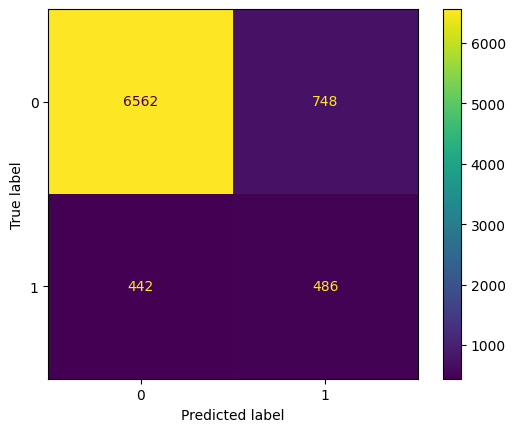

In [ ]:
cm_ada_rs = confusion_matrix(y_test, y_test_ada_rs)

ConfusionMatrixDisplay(confusion_matrix=cm_ada_rs).plot();

In [ ]:
true_negative_tn_ada_rs = cm_ada_rs[0,0]
false_negative_fn_ada_rs = cm_ada_rs[1,0]
true_positive_tp_ada_rs = cm_ada_rs[1,1]
false_positive_fp_ada_rs = cm_ada_rs[0,1]

### 4.1.6. Business Metrics

In [ ]:
model_profit_ada_rs      = ( (true_positive_tp_ada_rs * bank_profit) ).round()
model_deposit_ada_rs     = ( (true_positive_tp_ada_rs * 250) ).round()
model_total_cost_ada_rs  = ( (false_positive_fp_ada_rs + true_positive_tp_ada_rs) * call_cost ).round()
model_conv_rate_ada_rs   = ( true_positive_tp_ada_rs / (true_positive_tp_ada_rs + false_positive_fp_ada_rs) ).round(2)
model_net_profit_ada_rs  = ( model_profit_ada_rs - model_total_cost_ada_rs ).round()
model_net_revenue_ada_rs = ( model_deposit_ada_rs - model_total_cost_ada_rs ).round()
model_roi_ada_rs         = ( model_deposit_ada_rs/model_total_cost_ada_rs ).round(2)
model_net_roi_ada_rs     = ( model_net_profit_ada_rs/model_total_cost_ada_rs ).round(2)

In [ ]:
ada_rs_summary_data = [
                        ['Deposit', model_deposit_ada_rs],
                        ['Profit', model_profit_ada_rs],
                        ['Expenses', model_total_cost_ada_rs],
                        ['Net ROI', model_net_roi_ada_rs],
                        ['Conversion Rate', model_conv_rate_ada_rs],
                        ]
ada_rs_summary = pd.DataFrame(ada_rs_summary_data, columns=['Metric (GradientBoosting RS Tuned)', 'Value'])
ada_rs_summary

,Metric (GradientBoosting RS Tuned),Value
0,Deposit,121500.00
1,Profit,3390.00
2,Expenses,129.00
3,Net ROI,25.28
4,Conversion Rate,0.39


## 4.2 Gradient Boosting

### 4.2.1 Declaring Tuning Pipeline

In [ ]:
# param_gb_randomizedsearch = {
#     'learning_rate': np.arange(0.01, 0.2, 0.01), 
#     'n_estimators': [100, 200, 300, 400],  
#     'max_depth': [3, 5, 7, 9],  
# }

# param_gb_randomizedsearch = {
#     'learning_rate': np.arange(0.05, 0.15, 0.01), 
#     'n_estimators': [100, 150, 200, 250],  
#     'max_depth': [5, 7, 9, 11],  
# }

param_gb_randomizedsearch = {
    'learning_rate': np.arange(0.01, 0.2, 0.01), 
    'n_estimators': [200, 225, 250, 275],  
    'max_depth': [7, 9, 11, 13],  
}

In [119]:
gb_randomizedsearch_steps = pipe.steps + smote_pipe_steps + [('classifier', RandomizedSearchCV(GradientBoostingClassifier(), param_gb_randomizedsearch, n_iter=10, cv=5, scoring='f1'))]
gb_randomizedsearch_pipe = impipeline(steps=gb_randomizedsearch_steps)

### 4.2.2. Hyperparameter Tuning

In [120]:
gb_randomizedsearch = gb_randomizedsearch_pipe.fit(X_train, y_train)

In [121]:
gb_randomizedsearch[2].best_score_

np.float64(0.9115344552643107)

In [122]:
best_gb_randomizedsearch = gb_randomizedsearch[2].best_estimator_
gb_rs_best_steps = pipe.steps + smote_pipe_steps + [('GradientBoosting RandomizedSearch', best_gb_randomizedsearch)]
gb_rs_best_pipe = impipeline(steps=gb_rs_best_steps)

gb_rs_best_pipe.fit(X_train, y_train)

,steps,"[('feature engineering', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehot_encoding', ...), ('binary_encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [123]:
y_train_gb_rs = gb_rs_best_pipe.predict(X_train)
y_test_gb_rs = gb_rs_best_pipe.predict(X_test)

### 4.2.3. Evaluation Metrics

In [124]:
# Evaluate the performance
f1_train_gb_rs = f1_score(y_train, y_train_gb_rs)
f1_test_gb_rs = f1_score(y_test, y_test_gb_rs)
conv_rate_test_gb_rs = conv_rate_func(y_test, y_test_gb_rs)
roi_test_gb_rs = roi_func(y_test, y_test_gb_rs)

print("Evaluation Metrics")
gb_rs = {
    "Metric": [ "F1 Train",      "F1 Test",     "Conversion Rate Test Set",     "ROIConversion Rate Test Set"],
    "Value": [  f1_train_gb_rs,  f1_test_gb_rs,  conv_rate_test_gb_rs,           roi_test_gb_rs]
}

# Create DataFrame
df_gb_rs = pd.DataFrame(gb_rs)
df_gb_rs

Evaluation Metrics


,Metric,Value
0,F1 Train,0.795699
1,F1 Test,0.405871
2,Conversion Rate Test Set,49.765258
3,ROIConversion Rate Test Set,32.058350


### 4.2.4. Classification Report

In [125]:
print(classification_report(y_test, y_test_gb_rs))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7310
           1       0.50      0.34      0.41       928

    accuracy                           0.89      8238
   macro avg       0.71      0.65      0.67      8238
weighted avg       0.87      0.89      0.88      8238



### 4.2.5. Confusion Matrix

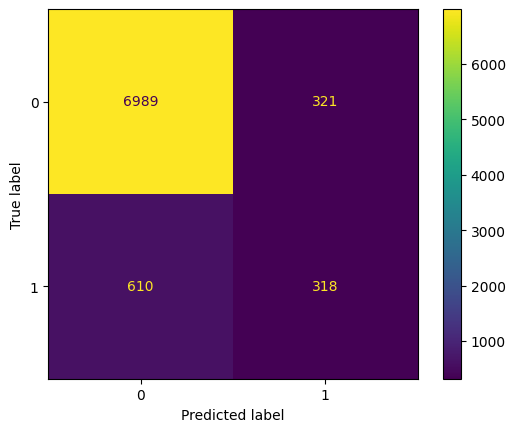

In [126]:
cm_gb_rs = confusion_matrix(y_test, y_test_gb_rs)

ConfusionMatrixDisplay(confusion_matrix=cm_gb_rs).plot();

In [127]:
true_negative_tn_gb_rs = cm_gb_rs[0,0]
false_negative_fn_gb_rs = cm_gb_rs[1,0]
true_positive_tp_gb_rs = cm_gb_rs[1,1]
false_positive_fp_gb_rs = cm_gb_rs[0,1]

### 4.2.6. Business Metrics

In [128]:
model_profit_gb_rs      = ( (true_positive_tp_gb_rs * bank_profit) ).round()
model_deposit_gb_rs     = ( (true_positive_tp_gb_rs * 250) ).round()
model_total_cost_gb_rs  = ( (false_positive_fp_gb_rs + true_positive_tp_gb_rs) * call_cost ).round()
model_conv_rate_gb_rs   = ( true_positive_tp_gb_rs / (true_positive_tp_gb_rs + false_positive_fp_gb_rs) ).round(2)
model_net_profit_gb_rs  = ( model_profit_gb_rs - model_total_cost_gb_rs ).round()
model_net_revenue_gb_rs = ( model_deposit_gb_rs - model_total_cost_gb_rs ).round()
model_roi_gb_rs         = ( model_deposit_gb_rs/model_total_cost_gb_rs ).round(2)
model_net_roi_gb_rs     = ( model_net_profit_gb_rs/model_total_cost_gb_rs ).round(2)

In [129]:
gb_rs_summary_data = [
                        ['Deposit', model_deposit_gb_rs],
                        ['Profit', model_profit_gb_rs],
                        ['Expenses', model_total_cost_gb_rs],
                        ['Net ROI', model_net_roi_gb_rs],
                        ['Conversion Rate', model_conv_rate_gb_rs],
                        ]
gb_rs_summary = pd.DataFrame(gb_rs_summary_data, columns=['Metric (GradientBoosting RS Tuned)', 'Value'])
gb_rs_summary

,Metric (GradientBoosting RS Tuned),Value
0,Deposit,79500.0
1,Profit,2218.0
2,Expenses,67.0
3,Net ROI,32.1
4,Conversion Rate,0.5


# 5. Business & Model Metrics Performance Summary

In [148]:
business_summary_data = [
        ['Non Model', unseen_total_cost_sum, unseen_revenue, unseen_net_profit, unseen_conv_rate, unseen_net_roi],
        ['Model AdaBoost Tuned', model_total_cost_ada_rs, model_deposit_ada_rs, model_net_profit_ada_rs, model_conv_rate_ada_rs, model_net_roi_ada_rs],
        ['Model Gradient Boosting Tuned', model_total_cost_gb_rs, model_deposit_gb_rs, model_net_profit_gb_rs, model_conv_rate_gb_rs, model_net_roi_gb_rs],
        ]
business_summary = pd.DataFrame(business_summary_data, columns=['Type', 'Total Cost', 'Deposit', 'Net Profit', 'Conversion Rate', 'Net ROI'])
business_summary

,Type,Total Cost,Deposit,Net Profit,Conversion Rate,Net ROI
0,Non Model,2578.0,232000,3895.0,0.11,1.51
1,Model AdaBoost Tuned,129.0,121500,3261.0,0.39,25.28
2,Model Gradient Boosting Tuned,67.0,79500,2151.0,0.50,32.10


In [149]:
model_summary_data = [
        ['Model AdaBoost Tuned', round(f1_train_ada_rs,4), round(f1_test_ada_rs,4), round(abs(round(f1_train_ada_rs,4) - round(f1_test_ada_rs,4)),4)],
        ['Model Gradient Boosting Tuned', round(f1_train_gb_rs,4), round(f1_test_gb_rs,4), round(abs(round(f1_train_gb_rs,4) - round(f1_test_gb_rs,4)),4)],
        ]
model_summary = pd.DataFrame(model_summary_data, columns=['Type', 'F1 Train', 'F1 Score', 'F1 Diff'])
model_summary

,Type,F1 Train,F1 Score,F1 Diff
0,Model AdaBoost Tuned,0.4816,0.4589,0.0227
1,Model Gradient Boosting Tuned,0.7957,0.4059,0.3898


# 6. Feature Importance

## Method 1

In [150]:
column_names = pipecheck.named_steps['feature engineering'].get_feature_names_out()

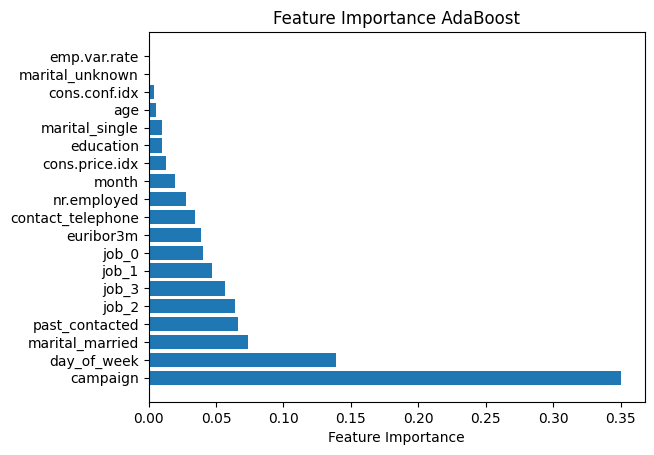

In [151]:
feature_importances_ada = ada_rs_best_pipe.named_steps['AdaBoost RandomizedSearch'].feature_importances_

feature_importances_ada_df = pd.DataFrame({
        'Feature': column_names,
        'Importance': feature_importances_ada
    })
sorted_ada_fi_df = feature_importances_ada_df.sort_values(by='Importance', ascending=False)

plt.barh(sorted_ada_fi_df['Feature'], sorted_ada_fi_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance AdaBoost')
plt.show()

## Method 2

In [168]:
%pip install git

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement git (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for git


In [166]:
# Apply preprocessing to get the transformed feature names
X_train_tf = preprocessor.transform(X_train)
X_test_tf = preprocessor.transform(X_test)

# Feature name
unique_feature_names = ada_rs_best_pipe[0].get_feature_names_out()

# create a SHAP TreeExplainer
explainer = shap.TreeExplainer(ada_rs_best_pipe.named_steps['AdaBoost RandomizedSearch'])

# calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_tf)

# visualize global feature importance
shap.summary_plot(shap_values, X_test_tf,
                  feature_names=unique_feature_names,
                  title="SHAP Summary Plot",
                  plot_size=(10, 6))

InvalidModelError: Model type not yet supported by TreeExplainer: <class 'sklearn.ensemble._weight_boosting.AdaBoostClassifier'>

# 7. Counterfactual

## 7.1. Counterfactual Set Up

In [169]:
cf_df = X_train.copy()

# Specify Numerical Columns
numeric_features = list(cf_df.select_dtypes(include=['number']).columns)

cf_df['Deposit'] = y_train.reset_index(drop=True)

# Define the Data Interface
data_interface = dice_ml.Data(dataframe=cf_df, continuous_features=numeric_features, outcome_name='Deposit')

# Define the Model Interface
model_interface = dice_ml.Model(model=ada_rs_best_pipe, backend='sklearn')

# Initialize Dice
dice = Dice(data_interface, model_interface)

In [195]:
int(X_test.sample(n=1).index[0])

26130

In [170]:
cf_df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
11491,37,services,married,5,no,unknown,unknown,telephone,6,5,...,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,0,0.0
24682,35,blue-collar,married,5,unknown,yes,no,cellular,11,1,...,999,1,failure,-0.1,93.200,-42.0,4.191,5195.8,1,0.0
37911,34,technician,married,6,no,yes,no,cellular,9,3,...,999,0,nonexistent,-3.4,92.379,-29.8,0.813,5017.5,0,NaN
519,42,admin.,married,1,no,no,no,telephone,5,2,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0.0
8013,37,admin.,married,7,no,yes,no,telephone,6,1,...,999,0,nonexistent,1.4,94.465,-41.8,4.865,5228.1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,50,blue-collar,divorced,2,no,no,no,telephone,6,3,...,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,0,0.0
25704,44,admin.,single,7,no,no,no,cellular,11,3,...,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,0,0.0
36747,47,admin.,single,7,no,yes,no,cellular,6,1,...,999,0,nonexistent,-2.9,92.963,-40.8,1.281,5076.2,0,NaN
32334,42,blue-collar,married,2,unknown,no,no,cellular,5,5,...,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,0,0.0


In [214]:
sample = int(X_test.sample(n=1).index[0])

# Generate Counterfactuals
pd.set_option('display.max_columns', None)
cf = dice.generate_counterfactuals(X_test.reset_index(drop=True).loc[[ sample ]], desired_class='opposite', total_CFs=3,
                                   features_to_vary='all')

# Display
cf.visualize_as_dataframe(show_only_changes=True)

# Store Generated Counterfactual Instance
cf_sample_1 = cf.cf_examples_list[0].final_cfs_df



100%|██████████| 1/1 [00:01<00:00,  1.95s/it]

Query instance (original outcome : 0)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,42,admin.,divorced,7,no,yes,no,telephone,5,5,397,1,999,0,nonexistent,1.1,93.994003,-36.400002,4.857,5191.0,0,0



Diverse Counterfactual set (new outcome: 1)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,-,-,-,-,unknown,no,-,-,-,-,-,-,-,-,-,-,-,-,0.753,-,-,1
1,-,-,single,-,-,-,-,cellular,-,-,-,-,-,-,-,-,-,-32.4,-,-,-,1
2,-,-,single,-,-,-,-,-,-,-,-,-,287,-,-,-,-,-,2.107,-,-,1


## 7.2 Generating Probabilities

### 7.2.1. Generating Counterfactual (1)

In [179]:
# Get the probability for the positive class (Deposit) for the counterfactual
probability_sample_1 = ada_rs_best_pipe.predict_proba(cf_sample_1)[0, 1]
probability_sample_1

np.float64(0.5013928885483211)

In [226]:
sample = int(X_test.sample(n=1).index[0])

# Generate Counterfactuals
pd.set_option('display.max_columns', None)
cf = dice.generate_counterfactuals(X_test.reset_index(drop=True).loc[[ sample ]], desired_class='opposite', total_CFs=3,
                                   features_to_vary='all')

# Display
cf.visualize_as_dataframe(show_only_changes=True)

# Store Generated Counterfactual Instance
cf_sample_2 = cf.cf_examples_list[0].final_cfs_df

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:01<00:00,  1.27s/it]

Query instance (original outcome : 0)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,40,technician,married,6,no,yes,no,cellular,5,4,580,1,999,1,failure,-1.8,92.892998,-46.200001,1.266,5099.100098,1,0



Diverse Counterfactual set (new outcome: 1)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,-,-,-,-,-,-,-,-,3,-,-,-,-,-,-,-,-,-35.9,-,-,-,1
1,-,-,-,-,yes,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1
2,-,-,-,-,-,no,-,-,3,-,-,-,-,-,-,-,-,-,-,-,-,1


### 7.2.2. Generating Counterfactual (2)

In [244]:
# Get the probability for the positive class (Deposit) for the counterfactual
probability_sample2 = ada_rs_best_pipe.predict_proba(cf_sample_2)[0, 1]
probability_sample2

np.float64(0.5041635734881935)

In [243]:
sample = int(X_train.sample(n=1).index[0])

# Generate Counterfactuals
pd.set_option('display.max_columns', None)
cf = dice.generate_counterfactuals(X_test.reset_index(drop=True).loc[[ sample ]], desired_class='opposite', total_CFs=3,
                                   features_to_vary='all')

# Display
cf.visualize_as_dataframe(show_only_changes=True)

# Store Generated Counterfactual Instance
cf_sample_3 = cf.cf_examples_list[0].final_cfs_df

100%|██████████| 1/1 [00:05<00:00,  5.03s/it]

Query instance (original outcome : 0)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,35,blue-collar,married,4,unknown,no,no,telephone,6,5,76,12,999,0,nonexistent,1.4,94.464996,-41.799999,4.959,5228.100098,0,0



Diverse Counterfactual set (new outcome: 1)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,-,-,-,-,-,-,-,cellular,12,-,-,-,-,2,-,-,-,-,0.795,-,-,1
1,-,-,-,-,-,unknown,-,cellular,-,4,-,-,-,7,-,-,-,-,2.546,-,-,1
2,-,-,-,-,-,unknown,-,cellular,-,4,-,-,-,-,-,-,-,-,2.546,-,-,1


### 7.2.3. Generating Counterfactual (3)

In [245]:
# Get the probability for the positive class (Deposit) for the counterfactual
probability_sample3 = ada_rs_best_pipe.predict_proba(cf_sample_3)[0, 1]
probability_sample3

np.float64(0.5170717718641128)

In [255]:
sample = int(X_train.sample(n=1).index[0])

# Generate Counterfactuals
pd.set_option('display.max_columns', None)
cf = dice.generate_counterfactuals(X_test.reset_index(drop=True).loc[[ sample ]], desired_class='opposite', total_CFs=3,
                                   features_to_vary='all')
# Display
cf.visualize_as_dataframe(show_only_changes=True)

# Store Generated Counterfactual Instance
cf_sample_4 = cf.cf_examples_list[0].final_cfs_df

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:02<00:00,  2.64s/it]

Query instance (original outcome : 0)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,30,admin.,single,7,no,no,no,cellular,7,1,171,4,999,0,nonexistent,1.4,93.917999,-42.700001,4.962,5228.100098,0,0



Diverse Counterfactual set (new outcome: 1)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,-,-,-,-,-,-,yes,-,-,-,-,-,-,-,-,-,-,-,-,-,-,1
1,-,-,-,-,-,-,-,-,-,-,4706,-,-,-,-,-,-,-,-,-,-,1
2,-,-,-,-,-,-,-,-,-,-,3836,-,-,-,-,-,-,-,-,-,-,1


### 7.2.4. Generating Counterfactual (4)

In [256]:
# Get the probability for the positive class (Deposit) for the counterfactual
probability_sample4 = ada_rs_best_pipe.predict_proba(cf_sample_4)[0, 1]
probability_sample4

np.float64(0.5007372955857531)

In [ ]:
sample = int(X_test.sample(n=1).index[0])

# Generate Counterfactuals
pd.set_option('display.max_columns', None)
cf = dice.generate_counterfactuals(X_test.reset_index(drop=True).loc[[ sample ]], desired_class='opposite', total_CFs=3,
                                   features_to_vary='all')

# Display
cf.visualize_as_dataframe(show_only_changes=True)

# Store Generated Counterfactual Instance
counterfact = cf.cf_examples_list[0].final_cfs_df

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:02<00:00,  2.94s/it]

Query instance (original outcome : 0)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,26,blue-collar,single,5,no,no,no,telephone,5,5,213,4,999,0,nonexistent,1.1,93.994003,-36.400002,4.855,5191.0,0,0



Diverse Counterfactual set (new outcome: 1)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,past_contacted,Deposit
0,-,-,-,-,-,-,-,cellular,-,-,-,-,-,-,-,-,-,-,-,-,-,1
1,-,-,-,-,-,-,-,-,3,-,-,-,-,-,-,-,-,-,-,-,-,1
2,-,-,-,-,-,-,-,cellular,-,-,-,-,-,-,-,-,-,-,-,-,-,1
